# Проект: Приоритизация обращений
1. Описание задачи
    Основная цель проекта — разработать модель для ранжирования входящих обращений (лидов). Для каждого обращения необходимо оценить вероятность того, что в течение ближайших 5 дней после назначения произойдет успешное целевое действие.

    **Бизнес-ценность**: Использование модели позволяет операторам и партнерам в первую очередь обрабатывать наиболее перспективные обращения, тем самым повышая общую конверсию потока.

    **Метрика качества**: Daily Average Precision (среднее значение AP, рассчитанное отдельно за каждый день).
2. Разведочный анализ данных (EDA)
В ходе анализа были выявлены следующие ключевые моменты:

* Дисбаланс классов: Целевое действие происходит примерно в 20.7% случаев.
* Временная структура: Данные имеют четкую временную зависимость. Тест следует после обучающей, что диктует выбор стратегии валидации.
* Признаки активности: Наивысшую корреляцию с таргетом имеют агрегаты за длительные периоды (30 и 90 дней), такие как search_views_90d и item_views_90d.
* Пропуски: В данных присутствуют пропуски (до 5% в некоторых признаках), которые могут нести информацию (например, отсутствие активности в определенном окне).

3. Feature Engineering
Это наиболее важная часть решения, где удалось значительно обогатить базовый набор признаков:

    * 3.1. Базовые табличные признаки
Относительные показатели: Рассчитаны коэффициенты изменения активности, например, отношение просмотров за 1 день к просмотрам за 7 дней (item_views_1d / item_views_7d).
Агрегаты: Суммарная и максимальная активность по всем типам событий во всех временных окнах.
Конверсии: Вероятность успеха пользователя в прошлом на основе истории предыдущих назначений (leadgen_prev_positive_30d / leadgen_prev_answered_30d).
Взаимодействия: Перемножение признаков, например, цена лога на рейтинг продавца (item_price_log * seller_response_rate_30d).
    * 3.2. Признаки из events.csv
Использование дополнительных событий позволило вытащить свежие данные о поведении пользователя непосредственно перед назначением:

    Счетчики: Общее количество событий и количество событий по типам (call_click, chat_open и т.д.) строго до момента assignment_ts.
    Временные характеристики: Время с последнего события до назначения, общая длительность сессии пользователя.
    Статистика цен: Средняя и последняя цена просмотренных айтемов в истории событий.
Категориальные моды: Наиболее частые типы слотов (src_slot) и последовательностей (ctx_seq).

4. Моделирование и валидация
    * 4.1. Валидация
Использовалась Time-Series Validation (5 фолдов). Данные разбивались по датам таким образом, чтобы модель всегда обучалась на прошлом, а проверялась на будущем. Это исключает переобучение и утечки, связанные со временем.

    * 4.2. Алгоритмы
Был реализован ансамбль из двух градиентных бустингов:

    LightGBM: Эффективен для работы с табличными данными и пропусками.
    CatBoost: Отлично справляется с категориальными фичами (lead_source, region, event_type).
    * 4.3. Оптимизация и тюнинг
Для подбора гиперпараметров использовалась библиотека Optuna.
Adversarial Validation: Проведена проверка на сдвиг распределений между train и test. assignment_weekday был исключен, так как имел аномально высокий дрифт, что могло ухудшить обобщающую способность.
Ensemble: Финальный результат получен путем взвешенного усреднения рангов предсказаний LightGBM и CatBoost. Ранговое усреднение лучше подходит для метрики Precision/Recall, так как оно устойчиво к выбросам и разным шкалам скоров.

5. Результаты
Baseline (Logistic Regression): ~0.485 AP на валидации.
Итоговое решение (Ensemble): удалось достичь уровня ~0.609 Daily AP на валидационной выборке.
Основные факторы успеха: добавление фичей из events.csv, учет временного сдвига (Time-Series Split) и использование ансамбля моделей с оптимизацией весов через Optuna.

6. Воспроизводимость и ограничения
Код: Весь процесс от загрузки до формирования сабмита реализован в одном Jupyter Notebook.
Random Seed: Для всех операций зафиксирован SEED = 42.
Требования:
Не используются внешние API и LLM > 1B параметров.
Фичи строятся только на событиях event_ts < assignment_ts (защита от читинга).
Используются только open-source библиотеки (LightGBM, CatBoost, Optuna, Scikit-learn).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import gc, warnings

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import rankdata

import lightgbm as lgb
import catboost as cb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")

SEED     = 42
TARGET   = "target"
DATA_DIR = "data"
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

ЗАГРУЗКА ДАННЫХ

Пути к данным в папке data.

In [2]:
DATA_DIR = Path("data")

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["assignment_ts", "assignment_date"])
test  = pd.read_csv(f"{DATA_DIR}/test.csv",  parse_dates=["assignment_ts", "assignment_date"])
events = pd.read_csv(f"{DATA_DIR}/events.csv", parse_dates=["event_ts"])

train = train.sort_values("assignment_ts").reset_index(drop=True)
test  = test.sort_values("assignment_ts").reset_index(drop=True)
events = events.sort_values(["lead_id", "event_ts"]).reset_index(drop=True)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Events shape: {events.shape}")
print(f"\ntrain target mean: {train[TARGET].mean():.4f}")
print(f"train target sum:  {train[TARGET].sum()}")

Train shape: (13694, 119)
Test shape: (4306, 118)
Events shape: (254705, 7)

train target mean: 0.2075
train target sum:  2841


АНАЛИЗ ВРЕМЕННЫХ РЯДОВ (TRAIN VS TEST)

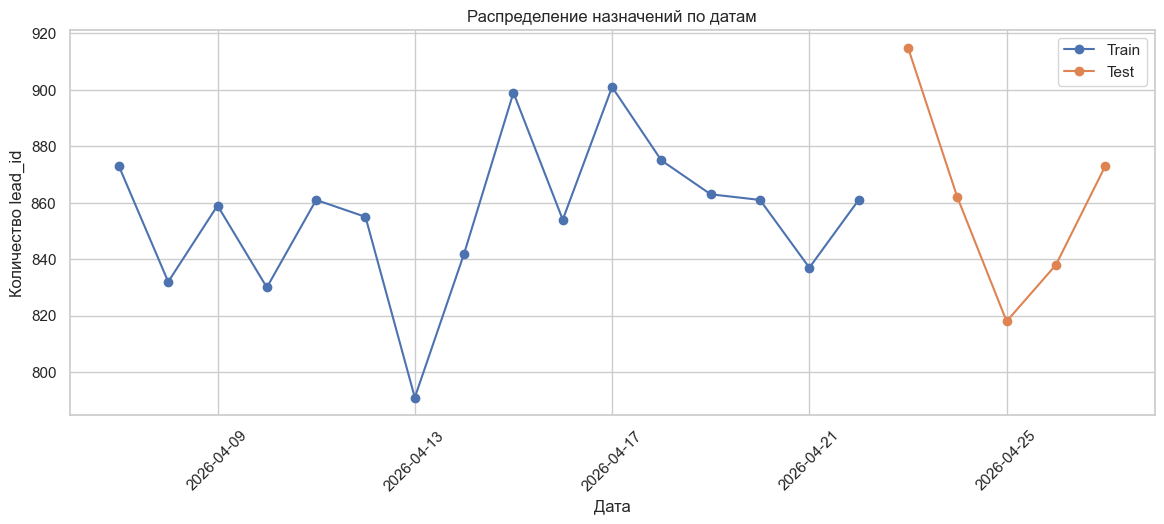

In [3]:
plt.figure(figsize=(14, 5))
train_daily = train.groupby('assignment_date').size()
test_daily = test.groupby('assignment_date').size()

plt.plot(train_daily.index, train_daily.values, label='Train', marker='o')
plt.plot(test_daily.index, test_daily.values, label='Test', marker='o')
plt.title("Распределение назначений по датам")
plt.xlabel("Дата")
plt.ylabel("Количество lead_id")
plt.legend()
plt.xticks(rotation=45)
plt.show()

АНАЛИЗ ПРОПУСКОВ


Топ-10 признаков по доле пропусков (Train):
seller_response_rate_30d     0.051701
leadgen_prev_positive_90d    0.033007
item_favorites_3d            0.032934
query_refinements_30d        0.032569
detail_expands_3d            0.032496
user_contacts_3d             0.031839
leadgen_prev_assigned_7d     0.031766
call_clicks_14d              0.031693
user_contacts_14d            0.031620
call_clicks_30d              0.031620
dtype: float64


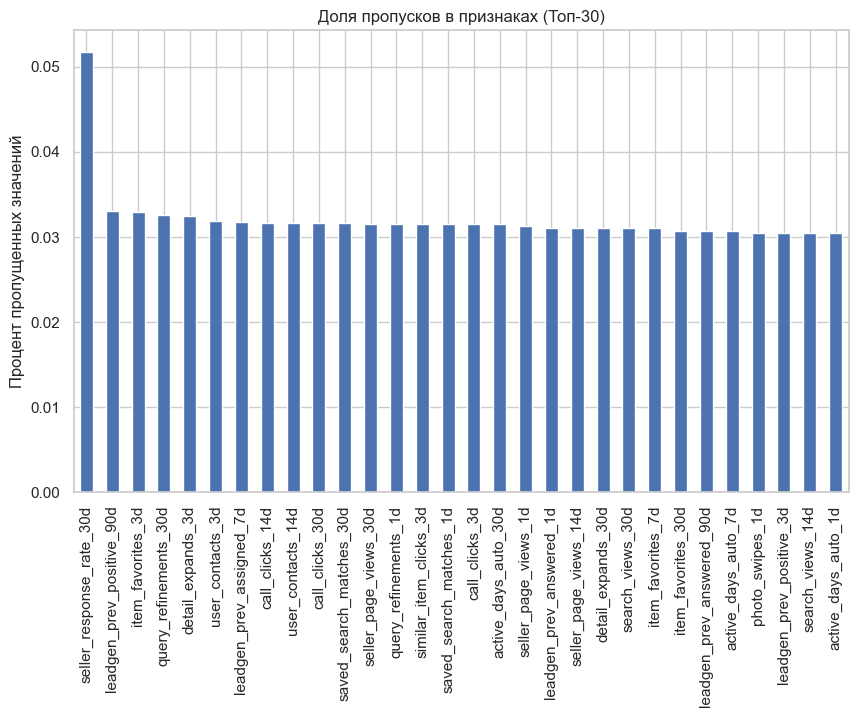

In [4]:
missing_train = train.isnull().mean().sort_values(ascending=False)
print("\nТоп-10 признаков по доле пропусков (Train):")
print(missing_train.head(10))

plt.figure(figsize=(10, 6))
missing_train[missing_train > 0][:30].plot(kind='bar')
plt.title("Доля пропусков в признаках (Топ-30)")
plt.ylabel("Процент пропущенных значений")
plt.show()

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ И КОНВЕРСИЯ (TARGET MEAN)

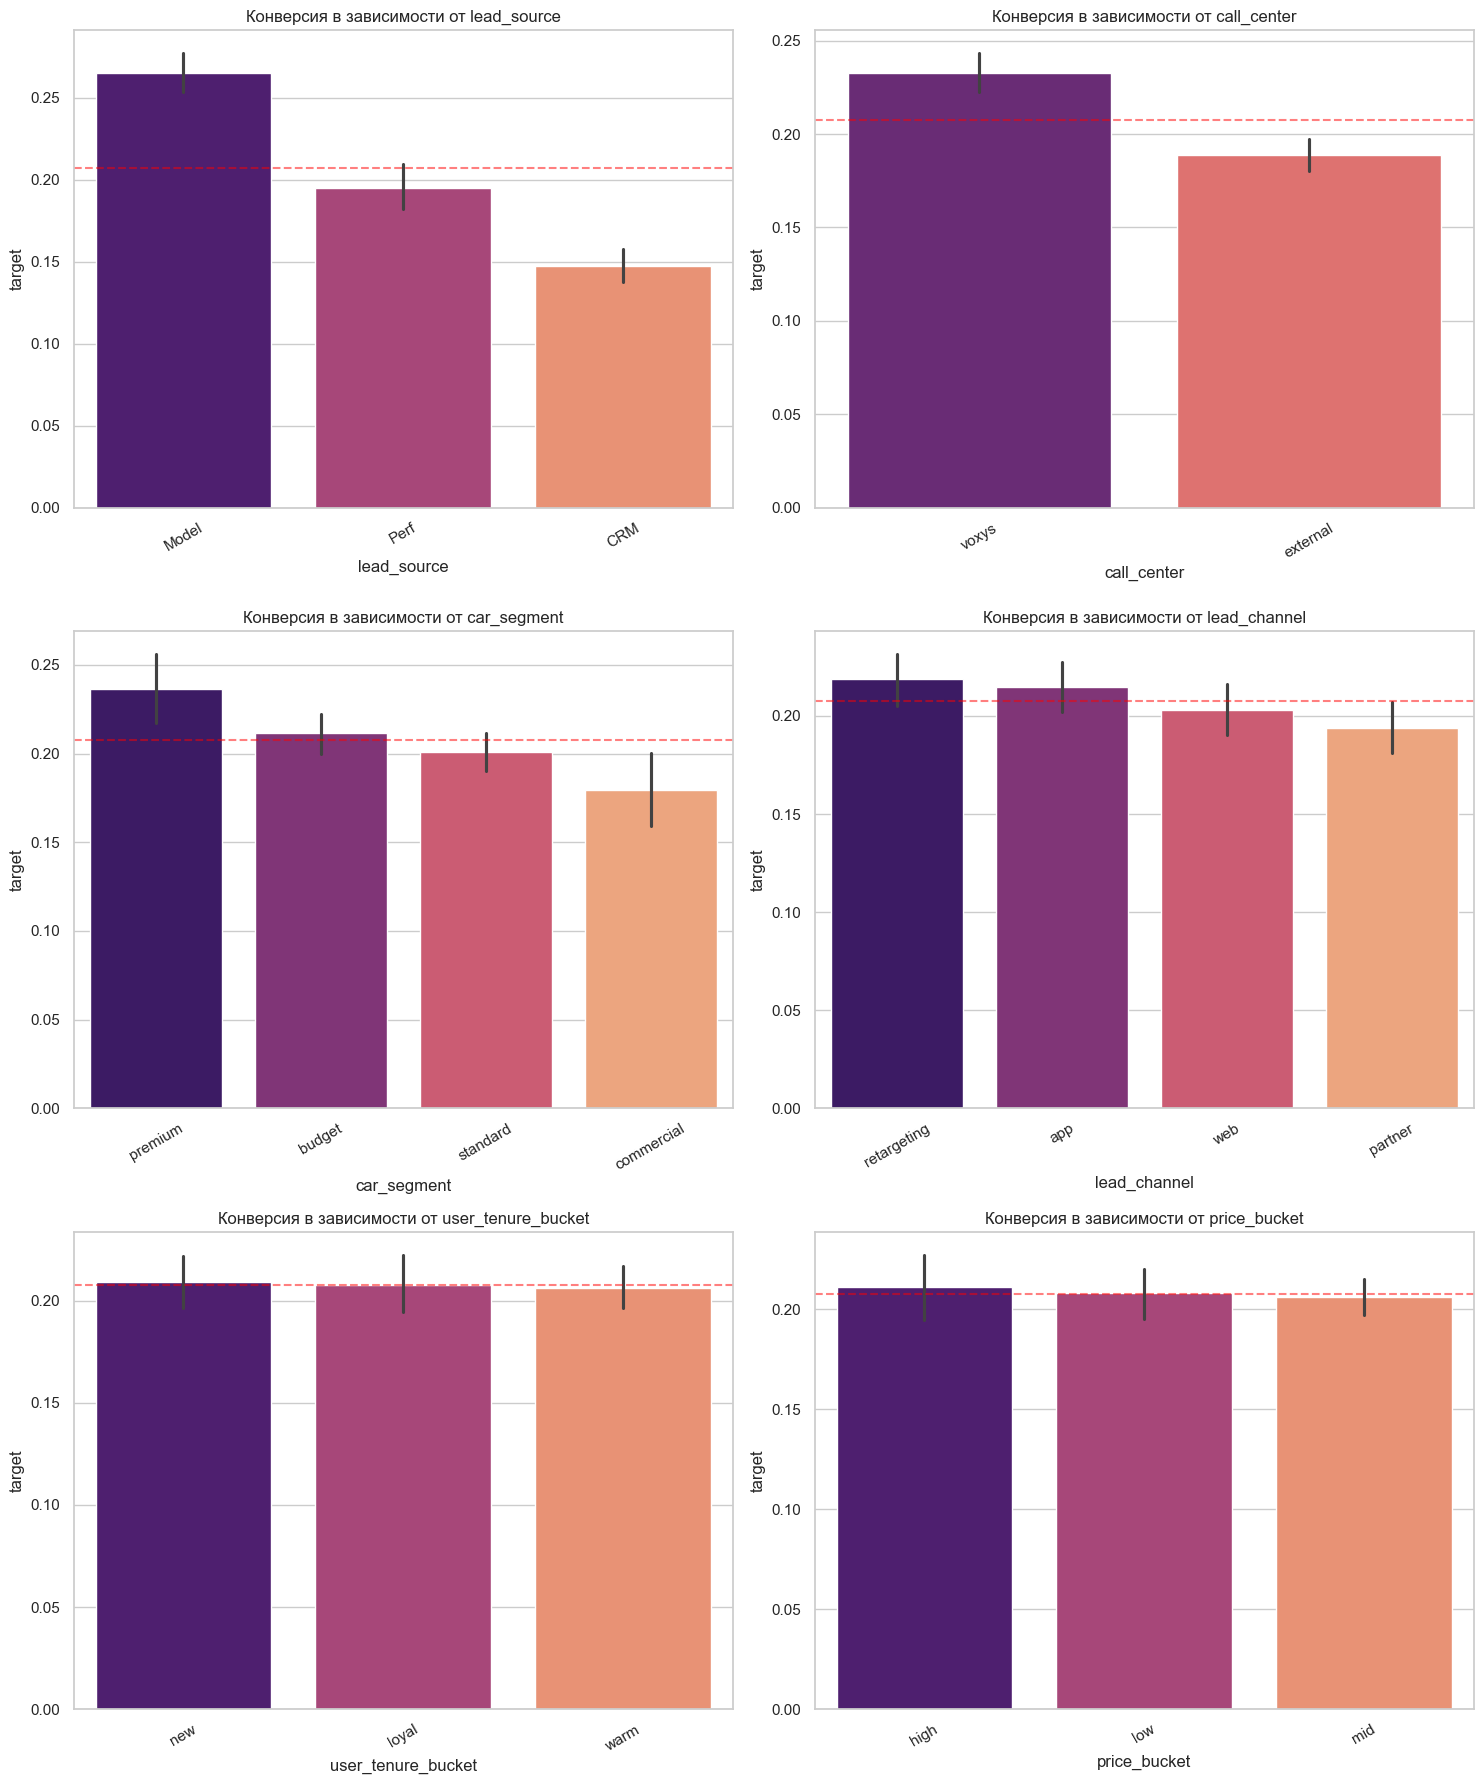

In [5]:
cat_cols = ['lead_source', 'call_center', 'car_segment', 'lead_channel', 'user_tenure_bucket', 'price_bucket']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train.groupby(col)['target'].mean().sort_values(ascending=False).index
    sns.barplot(data=train, x=col, y='target', ax=axes[i], order=order, palette='magma')
    axes[i].set_title(f"Конверсия в зависимости от {col}")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(train['target'].mean(), ls='--', color='red', alpha=0.5)

plt.tight_layout()
plt.show()

Cравнение распределения цен и возраста авто для разных классов.

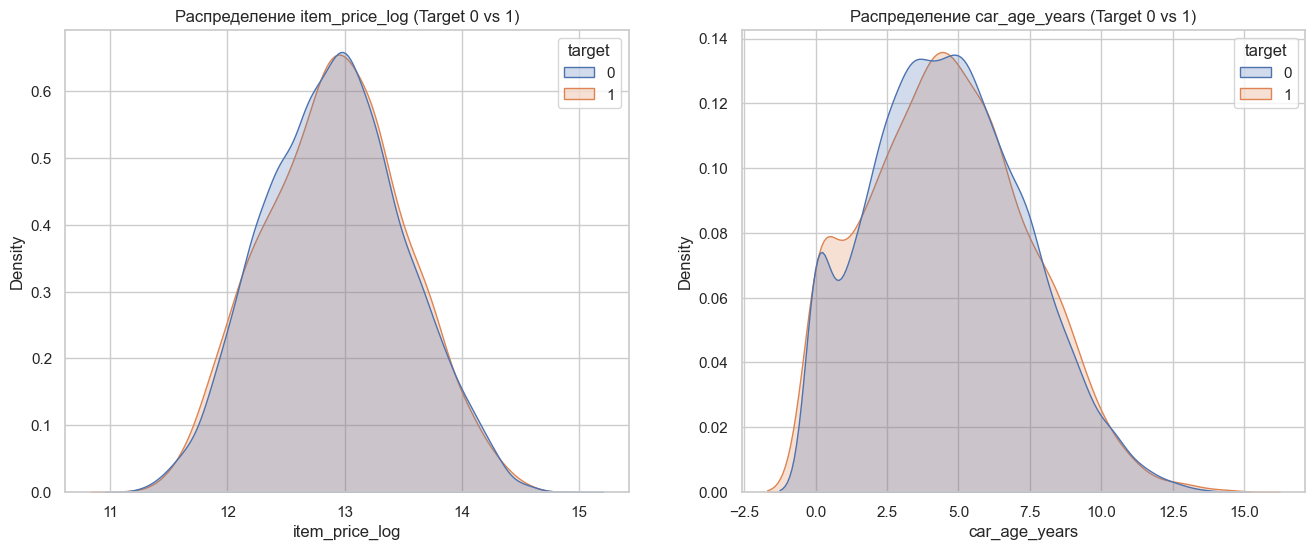

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=train, x='item_price_log', hue='target', common_norm=False, ax=ax1, fill=True)
ax1.set_title("Распределение item_price_log (Target 0 vs 1)")

sns.kdeplot(data=train, x='car_age_years', hue='target', common_norm=False, ax=ax2, fill=True)
ax2.set_title("Распределение car_age_years (Target 0 vs 1)")
plt.show()

АНАЛИЗ ФАЙЛА EVENTS.CSV + КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ТАРГЕТОМ

Проверка: сколько событий приходится на один lead_id

Берем только числовые признаки, исключая ID


Типы событий в events.csv:
event_type
item_view     120905
search         61101
favorite       26333
chat_open      24797
call_click     21569
Name: count, dtype: int64


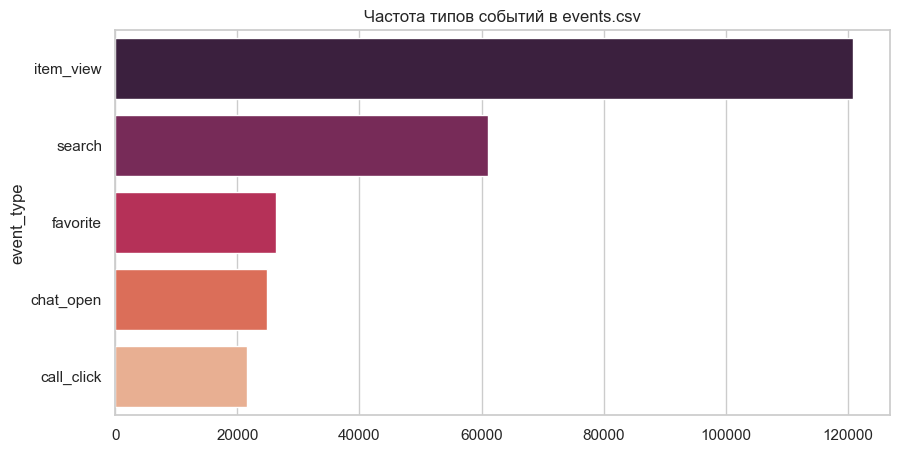


Статистика событий на один lead_id:
count    17988.000000
mean        14.159718
std          6.592222
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         35.000000
dtype: float64

Топ-10 признаков с самой высокой положительной корреляцией с target:
search_views_90d        0.272307
item_views_90d          0.265135
item_views_30d          0.253351
search_views_30d        0.251135
item_views_14d          0.251023
photo_swipes_30d        0.249721
search_views_14d        0.241066
active_days_auto_90d    0.235906
user_active_days_30d    0.232126
item_favorites_90d      0.231042
Name: target, dtype: float64

Топ-10 признаков с самой высокой отрицательной корреляцией с target:
assignment_hour             0.014276
leadgen_prev_positive_3d    0.007774
item_price_log              0.004367
seller_response_rate_30d    0.003124
seller_inventory_count      0.001914
assignment_weekday         -0.002126
car_age_years              -0.003500
mileage_km_log

In [7]:
print("\nТипы событий в events.csv:")
event_types = events['event_type'].value_counts()
print(event_types)

plt.figure(figsize=(10, 5))
sns.barplot(x=event_types.values, y=event_types.index, palette='rocket')
plt.title("Частота типов событий в events.csv")
plt.show()

events_per_lead = events.groupby('lead_id').size()
print(f"\nСтатистика событий на один lead_id:")
print(events_per_lead.describe())

numerical_cols = train.select_dtypes(include=[np.number]).columns
correlations = train[numerical_cols].corr()['target'].sort_values(ascending=False)

print("\nТоп-10 признаков с самой высокой положительной корреляцией с target:")
print(correlations[1:11])

print("\nТоп-10 признаков с самой высокой отрицательной корреляцией с target:")
print(correlations.tail(10))

АНАЛИЗ ЧАСА НАЗНАЧЕНИЯ

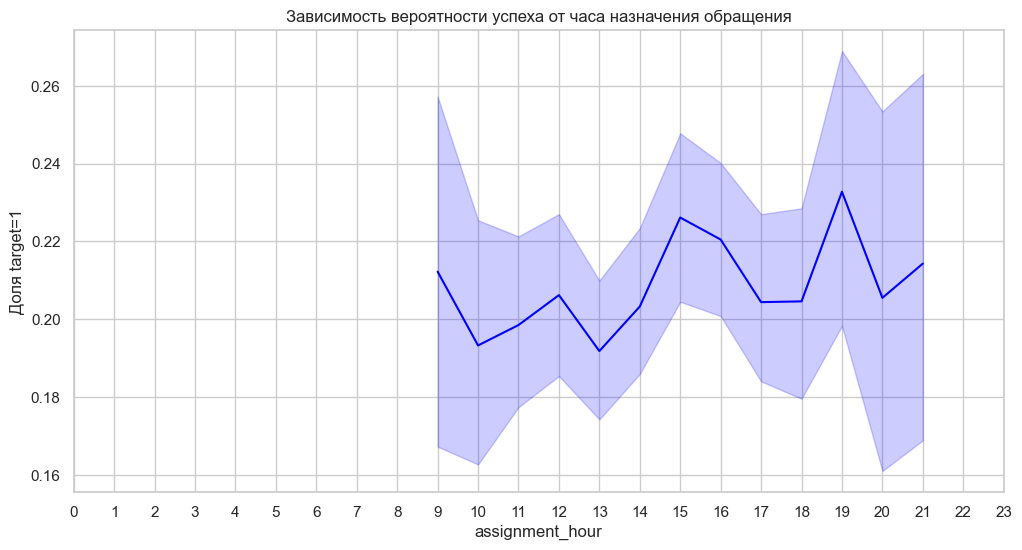

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=train, x='assignment_hour', y='target', estimator='mean', color='blue')
plt.title("Зависимость вероятности успеха от часа назначения обращения")
plt.ylabel("Доля target=1")
plt.xticks(range(0, 24))
plt.show()

Распределение таргета

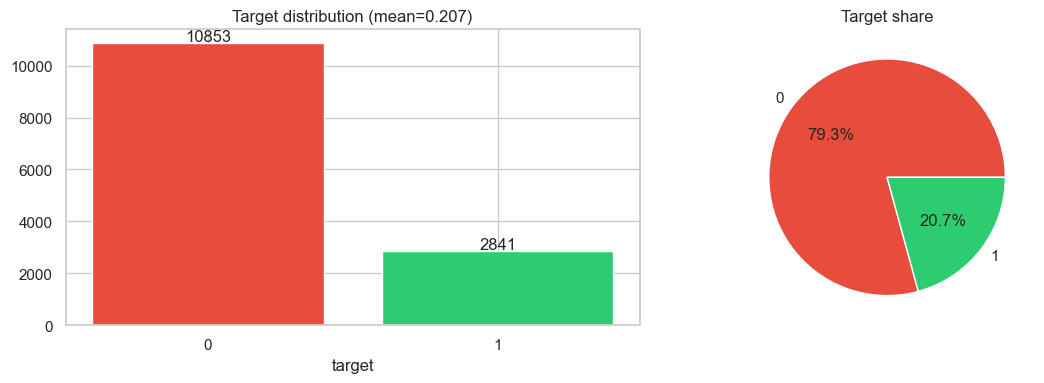

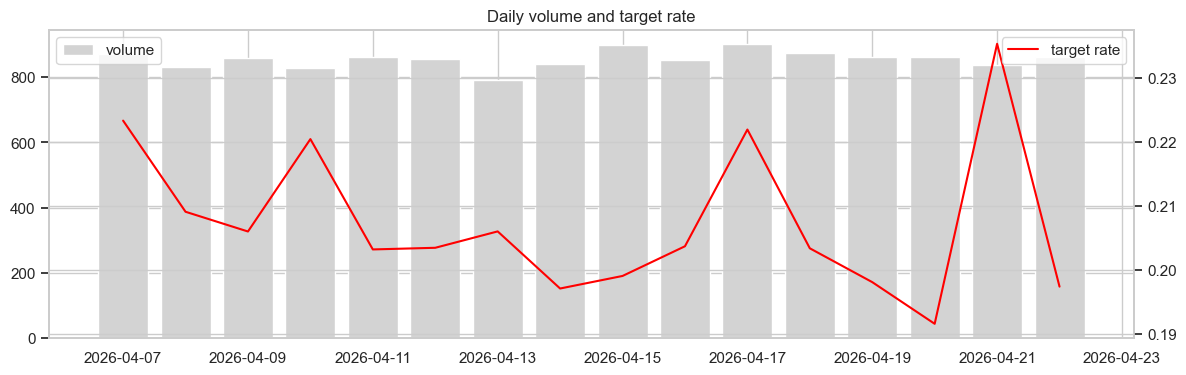

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train[TARGET].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=['#e74c3c','#2ecc71'])
axes[0].set_title(f"Target distribution (mean={train[TARGET].mean():.3f})")
axes[0].set_xticks([0,1])
axes[0].set_xlabel("target")
for i, v in enumerate(counts.values):
    axes[0].text(i, v+100, str(v), ha='center')

axes[1].pie(counts.values, labels=['0','1'], autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'])
axes[1].set_title("Target share")
plt.tight_layout(); plt.show()

train['assignment_date'] = pd.to_datetime(train['assignment_date'])
daily = train.groupby('assignment_date')[TARGET].agg(['mean','count'])
fig, ax = plt.subplots(figsize=(14,4))
ax.bar(daily.index, daily['count'], color='lightgray', label='volume')
ax2 = ax.twinx()
ax2.plot(daily.index, daily['mean'], color='red', label='target rate')
ax.set_title("Daily volume and target rate")
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.show()

In [10]:
ID_COLS = {"lead_id","user_id"}
TIME_COLS = {"assignment_ts","assignment_date"}
NON_FEATURE = ID_COLS | TIME_COLS | {TARGET}

feature_cols = [c for c in train.columns if c not in NON_FEATURE]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

train[num_cols].describe().T[['mean','std','min','25%','50%','75%','max']]

,mean,std,min,25%,50%,75%,max
assignment_hour,14.477654,2.800490,9.0,12.0,14.0,17.0,21.0
assignment_weekday,2.832408,1.937842,0.0,1.0,3.0,5.0,6.0
is_weekend,0.252227,0.434307,0.0,0.0,0.0,1.0,1.0
user_active_days_30d,12.383014,5.243909,0.0,9.0,12.0,15.0,36.0
user_age_days,415.899664,420.696887,1.0,118.0,286.0,572.0,4088.0
...,...,...,...,...,...,...,...
active_days_auto_3d,0.429785,0.688763,0.0,0.0,0.0,1.0,5.0
active_days_auto_7d,1.001281,1.153231,0.0,0.0,1.0,2.0,10.0
active_days_auto_14d,2.002409,1.788844,0.0,1.0,2.0,3.0,14.0
active_days_auto_30d,4.185855,3.102760,0.0,2.0,4.0,6.0,24.0


Корреляционная матрица

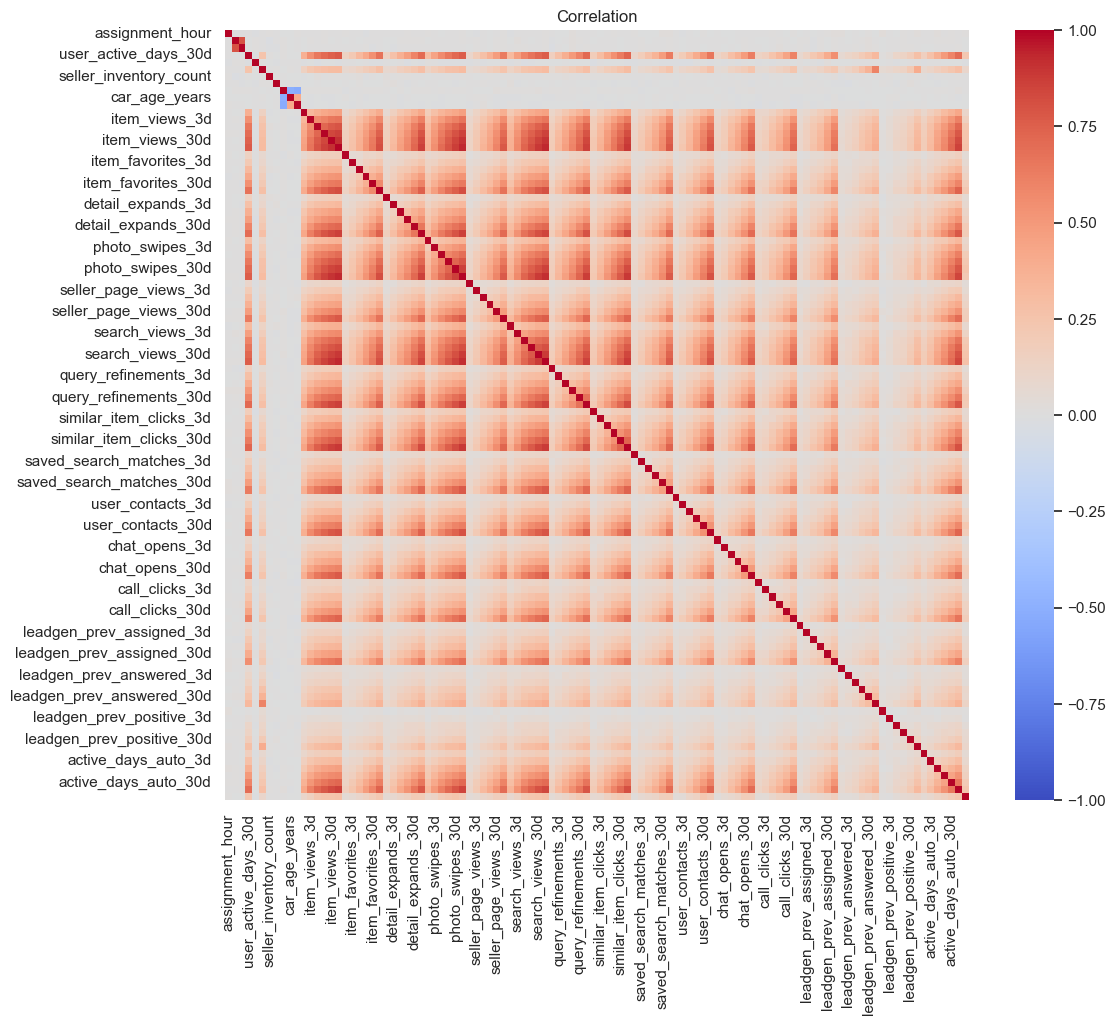

=== Top-15 |corr| with target ===
search_views_90d           0.272307
item_views_90d             0.265135
item_views_30d             0.253351
search_views_30d           0.251135
item_views_14d             0.251023
photo_swipes_30d           0.249721
search_views_14d           0.241066
active_days_auto_90d       0.235906
user_active_days_30d       0.232126
item_favorites_90d         0.231042
item_views_7d              0.230012
user_contacts_30d          0.223430
similar_item_clicks_30d    0.222730
photo_swipes_14d           0.222492
query_refinements_30d      0.213181
Name: target, dtype: float64


In [11]:
corr = train[num_cols + [TARGET]].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlation")
plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Top-15 |corr| with target")
print(target_corr.head(15))

Метрика Daily AP

In [12]:
def daily_average_precision(y_true, y_pred, dates):
    df = pd.DataFrame({'y_true': y_true.values, 'y_pred': y_pred, 'date': dates.values})
    aps = []
    for d, g in df.groupby('date'):
        if g['y_true'].sum() == 0 or g['y_true'].sum() == len(g):
            continue
        aps.append(average_precision_score(g['y_true'], g['y_pred']))
    return float(np.mean(aps)) if aps else 0.0

Базовый Feature Engineering

Конверсии воронки + Интеракции + Число NaN как фича

In [13]:
NUMERIC_SUFFIXES = ["1d", "3d", "7d", "14d", "30d", "90d"]

def make_base_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    prefixes = ["item_views", "item_favorites", "detail_expands", "photo_swipes",
                "seller_page_views", "search_views", "query_refinements",
                "similar_item_clicks", "saved_search_matches", "user_contacts",
                "chat_opens", "call_clicks", "leadgen_prev_assigned",
                "leadgen_prev_answered", "leadgen_prev_positive", "active_days_auto"]

    for p in prefixes:
        c1, c7, c30 = f"{p}_1d", f"{p}_7d", f"{p}_30d"
        if {c1, c7}.issubset(out.columns): out[f"{p}_ratio_1d_7d"] = out[c1] / (out[c7] + 1.0)
        if {c7, c30}.issubset(out.columns): out[f"{p}_ratio_7d_30d"] = out[c7] / (out[c30] + 1.0)

        cols = [f"{p}_{s}" for s in NUMERIC_SUFFIXES if f"{p}_{s}" in out.columns]
        if cols:
            out[f"{p}_sum_all"] = out[cols].sum(axis=1)
            out[f"{p}_max_all"] = out[cols].max(axis=1)

    a, b = "leadgen_prev_positive_30d", "leadgen_prev_answered_30d"
    if {a,b}.issubset(out.columns): out["leadgen_pos_rate_30d"] = out[a] / (out[b] + 1.0)
    a, b = "leadgen_prev_answered_30d", "leadgen_prev_assigned_30d"
    if {a,b}.issubset(out.columns): out["leadgen_answ_rate_30d"] = out[a] / (out[b] + 1.0)

    if "item_price_log" in out.columns and "seller_response_rate_30d" in out.columns:
        out["price_x_resp"] = out["item_price_log"] * out["seller_response_rate_30d"]
    if "car_age_years" in out.columns and "seller_inventory_count" in out.columns:
        out["age_x_inv"] = out["car_age_years"] * out["seller_inventory_count"]

    num_cols = [c for c in out.columns if c not in ["lead_id","user_id","assignment_ts","assignment_date",TARGET] and pd.api.types.is_numeric_dtype(out[c])]
    out["num_nans"] = out[num_cols].isna().sum(axis=1)
    return out

train_fe = make_base_features(train)
test_fe  = make_base_features(test)
print("Base FE done. train_fe shape:", train_fe.shape)

Base FE done. train_fe shape: (13694, 188)


Feature engineering events.csv

In [14]:
def make_event_features(base: pd.DataFrame, ev: pd.DataFrame) -> pd.DataFrame:
    out = base.copy()
    out["assignment_ts_shifted"] = out["assignment_ts"]  # + pd.Timedelta(microseconds=1) Лишнее
    merged = ev.merge(out[["lead_id", "assignment_ts", "assignment_ts_shifted"]], on="lead_id", how="inner")
    merged = merged[merged["event_ts"] < merged["assignment_ts_shifted"]]
    merged = merged.sort_values(["lead_id", "event_ts"])

    g = merged.groupby("lead_id")
    out = out.merge(g.size().rename("ev_total_count"), on="lead_id", how="left")
    out = out.merge(g["event_type"].nunique().rename("ev_unique_types"), on="lead_id", how="left")
    out = out.merge(g["event_ts"].max().rename("ev_last_ts"), on="lead_id", how="left")
    out = out.merge(g["event_ts"].min().rename("ev_first_ts"), on="lead_id", how="left")

    out["ev_hours_since_last"]  = (out["assignment_ts"] - out["ev_last_ts"]).dt.total_seconds() / 3600.0
    out["ev_hours_since_first"] = (out["assignment_ts"] - out["ev_first_ts"]).dt.total_seconds() / 3600.0
    out["ev_span_hours"]        = (out["ev_last_ts"] - out["ev_first_ts"]).dt.total_seconds() / 3600.0

    piv = merged.pivot_table(index="lead_id", columns="event_type", values="event_ts", aggfunc="count", fill_value=0)
    piv.columns = [f"ev_{c}_cnt" for c in piv.columns]
    out = out.merge(piv, on="lead_id", how="left")

    out["ev_first_type"] = out["lead_id"].map(merged.groupby("lead_id")["event_type"].first())
    out["ev_last_type"]  = out["lead_id"].map(merged.groupby("lead_id")["event_type"].last())

    merged["gap_hours"] = merged.groupby("lead_id")["event_ts"].diff().dt.total_seconds() / 3600.0
    gap_stats = merged.groupby("lead_id")["gap_hours"].agg(["mean", "std", "max"]).rename(columns={"mean": "ev_gap_mean", "std": "ev_gap_std", "max": "ev_gap_max"})
    out = out.merge(gap_stats, on="lead_id", how="left")

    price_g = merged.groupby("lead_id")["item_price_log"]
    out["ev_price_mean"] = out["lead_id"].map(price_g.mean())
    out["ev_price_std"]  = out["lead_id"].map(price_g.std())
    out["ev_price_last"] = out["lead_id"].map(merged.groupby("lead_id")["item_price_log"].last())

    for col in ["src_slot", "ctx_seq"]:
        out[f"ev_{col}_mode"] = out["lead_id"].map(merged.groupby("lead_id")[col].agg(lambda s: s.mode().iloc[0] if len(s) else np.nan))
        out[f"ev_{col}_nunique"] = out["lead_id"].map(merged.groupby("lead_id")[col].nunique())

    merged["d_to_assignment"] = (merged["assignment_ts"] - merged["event_ts"]).dt.total_seconds()/86400.0
    out = out.merge(merged[merged["d_to_assignment"] <= 1.0].groupby("lead_id").size().rename("ev_cnt_last1d"), on="lead_id", how="left")
    out = out.merge(merged[merged["d_to_assignment"] <= 5.0].groupby("lead_id").size().rename("ev_cnt_last5d"), on="lead_id", how="left")

    ev_numeric_cols = [c for c in out.columns if c.startswith("ev_") and pd.api.types.is_numeric_dtype(out[c])]
    out[ev_numeric_cols] = out[ev_numeric_cols].fillna(0)

    for c in ["ev_src_slot_mode", "ev_ctx_seq_mode", "ev_first_type", "ev_last_type"]:
        if c in out.columns: out[c] = out[c].fillna("NA").astype(str)

    out = out.drop(columns=['ev_last_ts', 'ev_first_ts', 'd_to_assignment', 'gap_hours', 'assignment_ts_shifted'], errors='ignore')

    del merged
    gc.collect()

    return out

train_fe = make_event_features(train_fe, events)
test_fe  = make_event_features(test_fe,  events)
print("Event FE done. train_fe shape:", train_fe.shape)

Event FE done. train_fe shape: (13694, 212)


Adversarial Validation

Модель показала, что признак день недели (assignment_weekday) имеет аномально высокую важность для классификатора is_test.

Убрали подсказку, которая позволяла модели понимать, из какого временного периода пришла строка, чтобы она фокусировалась на сути обращения, а не на дате.

In [15]:
feature_cols = [c for c in train_fe.columns if c not in ["lead_id","user_id","assignment_ts","assignment_date",TARGET]]

def adversarial_validation(train_df, test_df, feature_cols):
    tr = train_df[feature_cols].copy(); te = test_df[feature_cols].copy()
    tr["is_test"] = 0; te["is_test"] = 1
    comb = pd.concat([tr, te], ignore_index=True).reset_index(drop=True)
    for c in comb.select_dtypes("object").columns:
        comb[c] = comb[c].astype(str).fillna("NA")
        le = LabelEncoder().fit(comb[c])
        comb[c] = le.transform(comb[c])
    comb = comb.fillna(-999)
    params = dict(objective="binary", metric="auc", n_estimators=300, learning_rate=0.05,
               num_leaves=31, subsample=0.8, colsample_bytree=0.8, seed=SEED, verbose=-1)
    dtr = lgb.Dataset(comb[feature_cols], comb["is_test"])
    model = lgb.train(params, dtr)
    imp = pd.Series(model.feature_importance("gain"), index=feature_cols).sort_values(ascending=False)
    return imp

adv_imp = adversarial_validation(train_fe, test_fe, feature_cols)
drop_cols = adv_imp[adv_imp > 8000].index.tolist()
print("Dropping (distribution shift):", drop_cols)
feature_cols = [c for c in feature_cols if c not in drop_cols]

Dropping (distribution shift): ['assignment_weekday']


Categorical encoding & Time-Series CV

Принцип создания фолдов основан на хронологическом разделении данных по датам. Это стандарт, где важно избежать заглядывания в будущее.

fillna(-999) - значение, которое сильно выходит за рамки нормальных. Древовидные модели отлично понимают, что это специальное значение пропуска.

In [16]:
CAT_COLS = ["lead_source", "call_center", "region", "car_segment", "lead_channel",
            "user_tenure_bucket", "price_bucket", "ev_src_slot_mode", "ev_ctx_seq_mode",
            "ev_first_type", "ev_last_type"]

for c in CAT_COLS:
    if c in train_fe.columns and c in feature_cols:
        full = pd.concat([train_fe[c].astype(str), test_fe[c].astype(str)], axis=0)
        le = LabelEncoder().fit(full)
        train_fe[c] = le.transform(train_fe[c].astype(str))
        test_fe[c]  = le.transform(test_fe[c].astype(str))

num_cols = [c for c in train_fe[feature_cols].columns if pd.api.types.is_numeric_dtype(train_fe[c])]
train_fe[num_cols] = train_fe[num_cols].fillna(-999)
test_fe[num_cols] = test_fe[num_cols].fillna(-999)

def make_time_folds(df, n_splits=5):
    dates = sorted(df["assignment_date"].unique())
    fold_size = len(dates) // (n_splits + 1)
    folds = []
    for i in range(n_splits):
        val_start_idx = (i + 1) * fold_size
        val_end_idx = val_start_idx + fold_size if i < n_splits - 1 else len(dates)
        val_dates = set(dates[val_start_idx:val_end_idx])
        train_dates = set(dates[:val_start_idx])
        tr_idx = df.index[df["assignment_date"].isin(train_dates)].tolist()
        val_idx = df.index[df["assignment_date"].isin(val_dates)].tolist()
        folds.append((tr_idx, val_idx))
    return folds

folds = make_time_folds(train_fe)
print("Количество фолдов:", len(folds))

Количество фолдов: 5


In [17]:
pd.DataFrame(folds)

,0,1
0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1705, 1706, 1707, 1708, 1709, 1710, 1711, 171..."
1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[3394, 3395, 3396, 3397, 3398, 3399, 3400, 340..."
2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[5110, 5111, 5112, 5113, 5114, 5115, 5116, 511..."
3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[6743, 6744, 6745, 6746, 6747, 6748, 6749, 675..."
4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[8496, 8497, 8498, 8499, 8500, 8501, 8502, 850..."


Быстрая проверка на адекватность

In [18]:
tr_idx, val_idx = folds[-1]
X_tr, y_tr = train_fe.loc[tr_idx, feature_cols], train_fe.loc[tr_idx, TARGET]
X_val, y_val = train_fe.loc[val_idx, feature_cols], train_fe.loc[val_idx, TARGET]

cat_features_idx = [feature_cols.index(c) for c in CAT_COLS if c in feature_cols]

dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features_idx)
dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features_idx)

sanity_params = {
    'objective': 'binary', 'metric': 'average_precision',
    'learning_rate': 0.05, 'num_leaves': 63, 'verbose': -1, 'n_jobs': -1,
    'scale_pos_weight': 3, 'seed': SEED
}

model_sanity = lgb.train(sanity_params, dtrain, num_boost_round=1000,
                         valid_sets=[dval],
                         callbacks=[lgb.early_stopping(50)])

val_pred = model_sanity.predict(X_val)
sanity_ap = daily_average_precision(y_val, val_pred, train_fe.loc[val_idx, "assignment_date"])

print(f"Sanity Check Daily AP (default params, 1 fold): {sanity_ap:.5f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[152]	valid_0's average_precision: 0.606518
Sanity Check Daily AP (default params, 1 fold): 0.60899


Optuna для LightGBM

In [19]:
%%time

def objective_lgbm(trial):
    param = {
        'objective': 'binary', 'metric': 'average_precision',
        'verbosity': -1, 'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'learning_rate': 0.01,
        'seed': SEED
    }

    scores = []
    for tr_idx, val_idx in folds:
        X_tr, y_tr = train_fe.loc[tr_idx, feature_cols], train_fe.loc[tr_idx, TARGET]
        X_val, y_val = train_fe.loc[val_idx, feature_cols], train_fe.loc[val_idx, TARGET]

        cat_features_idx = [feature_cols.index(c) for c in CAT_COLS if c in feature_cols]
        dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features_idx)
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features_idx)

        model = lgb.train(param, dtrain, num_boost_round=3000, valid_sets=[dval],
                          callbacks=[lgb.early_stopping(50)])

        preds = model.predict(X_val)
        score = daily_average_precision(y_val, preds, train_fe.loc[val_idx, "assignment_date"])
        scores.append(score)

    return np.mean(scores)

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=100)
best_lgbm_params = study_lgbm.best_params
best_lgbm_params['learning_rate'] = 0.01
best_lgbm_params['objective'] = 'binary'
best_lgbm_params['seed'] = SEED
print("Лучшие параметры LGBM:", best_lgbm_params)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[201]	valid_0's average_precision: 0.516833
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1095]	valid_0's average_precision: 0.516209
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[455]	valid_0's average_precision: 0.569169
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[847]	valid_0's average_precision: 0.576863
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1032]	valid_0's average_precision: 0.613187
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[498]	valid_0's average_precision: 0.551934
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[622]	valid_0's average_precision: 0.521302
Training until val

Optuna для CatBoost

In [23]:
%%time

def objective_cb(trial):
    param = {
        'loss_function': 'Logloss', 'eval_metric': 'Logloss',
        'task_type': 'GPU', 'verbose': 50,
        'learning_rate': 0.01,
        'depth': trial.suggest_int('depth', 4, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_seed': SEED
    }
    scores = []
    for tr_idx, val_idx in folds:
        X_tr, y_tr = train_fe.loc[tr_idx, feature_cols], train_fe.loc[tr_idx, TARGET]
        X_val, y_val = train_fe.loc[val_idx, feature_cols], train_fe.loc[val_idx, TARGET]

        train_pool = cb.Pool(X_tr, y_tr, cat_features=CAT_COLS)
        val_pool = cb.Pool(X_val, y_val, cat_features=CAT_COLS)

        model = cb.CatBoostClassifier(**param, iterations=500, early_stopping_rounds=50)
        model.fit(train_pool, eval_set=val_pool)

        preds = model.predict_proba(val_pool)[:, 1]
        score = daily_average_precision(y_val, preds, train_fe.loc[val_idx, "assignment_date"])
        scores.append(score)

    return np.mean(scores)

study_cb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(objective_cb, n_trials=20)
best_cb_params = study_cb.best_params
best_cb_params['random_seed'] = SEED
print("Лучшие параметры CatBoost:", best_cb_params)

0:	learn: 0.6908049	test: 0.6910542	best: 0.6910542 (0)	total: 77.8ms	remaining: 38.8s
50:	learn: 0.6210812	test: 0.6319064	best: 0.6319064 (50)	total: 3.5s	remaining: 30.8s
100:	learn: 0.5813279	test: 0.6079250	best: 0.6079250 (100)	total: 4.83s	remaining: 19.1s
150:	learn: 0.5515757	test: 0.5951895	best: 0.5951895 (150)	total: 6.17s	remaining: 14.3s
200:	learn: 0.5302056	test: 0.5888116	best: 0.5888116 (200)	total: 7.53s	remaining: 11.2s
250:	learn: 0.5120272	test: 0.5843669	best: 0.5843669 (250)	total: 8.88s	remaining: 8.81s
300:	learn: 0.4954319	test: 0.5814720	best: 0.5814635 (299)	total: 10.2s	remaining: 6.76s
350:	learn: 0.4832161	test: 0.5792308	best: 0.5792308 (350)	total: 11.6s	remaining: 4.92s
400:	learn: 0.4694380	test: 0.5774894	best: 0.5774894 (400)	total: 12.9s	remaining: 3.19s
450:	learn: 0.4586904	test: 0.5768461	best: 0.5768461 (450)	total: 14.3s	remaining: 1.55s
499:	learn: 0.4485145	test: 0.5766917	best: 0.5764677 (479)	total: 15.6s	remaining: 0us
bestTest = 0.57646

Финальное ансамблирование и обучение на 100% данных

In [24]:
best_lgbm_params['seed'] = SEED
best_cb_params['random_seed'] = SEED

oof_lgbm = np.zeros(len(train_fe))
test_lgbm_cv = np.zeros(len(test_fe))
best_iters_lgbm = []

for fold_i, (tr_idx, val_idx) in enumerate(folds):
    print(f"LGBM Fold {fold_i+1}/{len(folds)}")
    X_tr, y_tr = train_fe.loc[tr_idx, feature_cols], train_fe.loc[tr_idx, TARGET]
    X_val, y_val = train_fe.loc[val_idx, feature_cols], train_fe.loc[val_idx, TARGET]

    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features_idx)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features_idx)

    model = lgb.train(best_lgbm_params, dtrain, num_boost_round=5000, valid_sets=[dval],
                      callbacks=[lgb.early_stopping(100)])

    oof_lgbm[val_idx] = model.predict(X_val)
    test_lgbm_cv += model.predict(test_fe[feature_cols]) / len(folds)
    best_iters_lgbm.append(model.best_iteration)

lgbm_cv_score = daily_average_precision(train_fe[TARGET], oof_lgbm, train_fe["assignment_date"])
print(f"LGBM OOF Daily AP: {lgbm_cv_score:.5f}")

print("Refitting LGBM on 100% train data...")
avg_best_iter = int(np.mean(best_iters_lgbm))
dtrain_full = lgb.Dataset(train_fe[feature_cols], label=train_fe[TARGET], categorical_feature=cat_features_idx)
model_lgbm_full = lgb.train(best_lgbm_params, dtrain_full, num_boost_round=avg_best_iter)
test_lgbm_refit = model_lgbm_full.predict(test_fe[feature_cols])


oof_cb = np.zeros(len(train_fe))
test_cb_cv = np.zeros(len(test_fe))
best_iters_cb = []

for fold_i, (tr_idx, val_idx) in enumerate(folds):
    print(f"CatBoost Fold {fold_i+1}/{len(folds)}")
    X_tr, y_tr = train_fe.loc[tr_idx, feature_cols], train_fe.loc[tr_idx, TARGET]
    X_val, y_val = train_fe.loc[val_idx, feature_cols], train_fe.loc[val_idx, TARGET]

    train_pool = cb.Pool(X_tr, y_tr, cat_features=CAT_COLS)
    val_pool = cb.Pool(X_val, y_val, cat_features=CAT_COLS)

    model = cb.CatBoostClassifier(**best_cb_params, iterations=3000, early_stopping_rounds=100, verbose=0, eval_metric='Logloss')
    model.fit(train_pool, eval_set=val_pool)

    oof_cb[val_idx] = model.predict_proba(val_pool)[:, 1]
    test_cb_cv += model.predict_proba(cb.Pool(test_fe[feature_cols], cat_features=CAT_COLS))[:, 1] / len(folds)
    best_iters_cb.append(model.best_iteration_)

cb_cv_score = daily_average_precision(train_fe[TARGET], oof_cb, train_fe["assignment_date"])
print(f"CatBoost OOF Daily AP: {cb_cv_score:.5f}")

print("Refitting CatBoost on 100% train data...")
avg_best_iter_cb = int(np.mean(best_iters_cb))
train_pool_full = cb.Pool(train_fe[feature_cols], train_fe[TARGET], cat_features=CAT_COLS)
model_cb_full = cb.CatBoostClassifier(**best_cb_params, iterations=avg_best_iter_cb, verbose=0, eval_metric='Logloss')
model_cb_full.fit(train_pool_full)
test_cb_refit = model_cb_full.predict_proba(cb.Pool(test_fe[feature_cols], cat_features=CAT_COLS))[:, 1]


print("Поиск оптимальных весов ансамбля...")

oof_lgbm_r = rankdata(oof_lgbm) / len(oof_lgbm)
oof_cb_r = rankdata(oof_cb) / len(oof_cb)

def blend_objective(trial):
    w1 = trial.suggest_float('w1', 0.0, 1.0)
    w2 = trial.suggest_float('w2', 0.0, 1.0)
    blend = (oof_lgbm_r * w1 + oof_cb_r * w2) / (w1 + w2 + 1e-7)
    return daily_average_precision(train_fe[TARGET], blend, train_fe["assignment_date"])

study_blend = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_blend.optimize(blend_objective, n_trials=300)
best_weights = [study_blend.best_params['w1'], study_blend.best_params['w2']]
print("Лучшие веса (LGBM, CB):", best_weights)

print("Формирование финального сабмита...")

test_lgbm_r = rankdata(test_lgbm_refit) / len(test_lgbm_refit)
test_cb_r = rankdata(test_cb_refit) / len(test_cb_refit)

LGBM Fold 1/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[716]	valid_0's binary_logloss: 0.426832
LGBM Fold 2/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[937]	valid_0's binary_logloss: 0.410907
LGBM Fold 3/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[922]	valid_0's binary_logloss: 0.377937
LGBM Fold 4/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[913]	valid_0's binary_logloss: 0.384902
LGBM Fold 5/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1270]	valid_0's binary_logloss: 0.377694
LGBM OOF Daily AP: 0.55195
Refitting LGBM on 100% train data...
CatBoost Fold 1/5
CatBoost Fold 2/5
CatBoost Fold 3/5
CatBoost Fold 4/5
CatBoost Fold 5/5
CatBoost OOF Daily AP: 0.53562
Refitting CatBoost on 100% train data...
Поиск оптимал

Подтягиваем предсказания к оригинальному порядку lead_id из файла test.csv

Читаем оригинал тестового файла, чтобы взять из него правильный порядок lead_id

In [25]:
final_test_scores = (test_lgbm_r * best_weights[0] + test_cb_r * best_weights[1]) / (sum(best_weights) + 1e-7)

preds_df = pd.DataFrame({
    'lead_id': test_fe['lead_id'].astype(str),
    'score': final_test_scores
})

original_test = pd.read_csv(DATA_DIR / "test.csv", usecols=['lead_id'])
original_test['lead_id'] = original_test['lead_id'].astype(str)

submission = original_test.merge(preds_df, on='lead_id', how='left')

assert len(submission) == len(original_test), "Количество строк не совпадает!"
submission['score'] = submission['score'].clip(0, 1)

submission.to_csv('submission.csv', index=False)
print("\nФайл submission.csv успешно создан!")


Файл submission.csv успешно создан!
